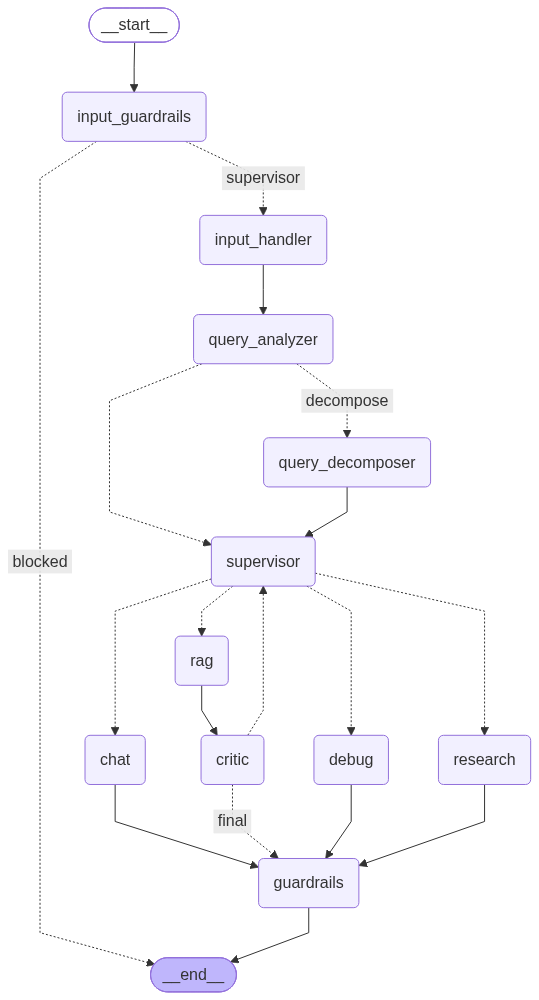

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from langgraph.graph import StateGraph, START, END
from supervisor_agent.state import AppState
from supervisor_agent.node import (
    supervisor_node,
    rag_node,
    research_node,
    debug_node,
    critic_node,
    specialist_router,
    critic_result_router,
    # chat_node
)
from supervisor_agent.node import chat_node
from output_guardrails.node import guardrails_node
from input_guardrails.node import input_guardrails_node
from input_handler.node import input_handler_node
from langgraph.checkpoint.memory import MemorySaver

from query_enhancer_agent.node import (query_analyzer_node,query_decomposer_node)

memory = MemorySaver()

builder = StateGraph(AppState)

def query_router(state: AppState):
    if state.get("should_decompose"):
        return "decompose"

    return "supervisor"

def input_guardrail_router(state):
    if state.get("input_blocked"):
        return "blocked"

    return "supervisor"

# Nodes
builder.add_node("input_guardrails",input_guardrails_node)
builder.add_node("supervisor",supervisor_node)
builder.add_node("rag",rag_node)
builder.add_node("research",research_node)
builder.add_node("debug",debug_node)
builder.add_node("critic",critic_node)
builder.add_node("guardrails", guardrails_node)
builder.add_node("input_handler",input_handler_node)
builder.add_node("query_analyzer",query_analyzer_node)
builder.add_node("query_decomposer",query_decomposer_node)
builder.add_node("chat", chat_node)

# Initial routing
builder.add_edge(START, "input_guardrails")

builder.add_conditional_edges(
    "input_guardrails",
    input_guardrail_router,
    {
        "supervisor": "input_handler",
        "blocked": END,
    }
)
builder.add_edge("input_handler","query_analyzer")

builder.add_conditional_edges(
    "query_analyzer",
    query_router,
    {
        "decompose": "query_decomposer",
        "supervisor": "supervisor",
    }
)
builder.add_edge("query_decomposer","supervisor")

builder.add_conditional_edges(
    "supervisor",
    specialist_router,
    {
        "rag": "rag",
        "research": "research",
        "debug": "debug",
        "chat": "chat",
    }
)

# Specialist → Supervisor
builder.add_edge("rag","critic")

builder.add_edge("research", "guardrails")
builder.add_edge("debug", "guardrails")
builder.add_edge("chat", "guardrails")

# Critic
builder.add_conditional_edges(
    "critic",
    critic_result_router,
    {
        "final": "guardrails",
        "supervisor": "supervisor",
    },
)
builder.add_edge("guardrails", END)

supervisor_graph = builder.compile(checkpointer=memory)
supervisor_graph